In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.chdir('../')

import pickle
from pathlib import Path
import time
import glob
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from pytorch_lightning.core.lightning import LightningModule
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

from utils.config_dataset import *
from utils.data_io import load_train_test_dataset, pickle_load
from utils.ClassCLF import CONDITION_CLF, CONDITION_CLF_TCN, CONDITION_CLF_TCN_WITH_MED
from utils.ClassDataset import MergedDataset

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_curve, precision_recall_curve

RANDOMSEED=2024
torch.manual_seed(RANDOMSEED)
np.random.seed(RANDOMSEED)

import warnings
warnings.filterwarnings("ignore")

# limit CPU cores used by the script
os.environ["OMP_NUM_THREADS"] = "32" # export OMP_NUM_THREADS=1
os.environ["OPENBLAS_NUM_THREADS"] = "32" # export OPENBLAS_NUM_THREADS=1
os.environ["MKL_NUM_THREADS"] = "32" # export MKL_NUM_THREADS=1
os.environ["VECLIB_MAXIMUM_THREADS"] = "32" # export VECLIB_MAXIMUM_THREADS=1
os.environ["NUMEXPR_NUM_THREADS"] = "32" # export NUMEXPR_NUM_THREADS=1

In [2]:
base_path = 'processed-merge-v3/'
device = 'cuda'

# Load dataset
DATA = load_train_test_dataset(
    batchsize=32,
    sample_dict_file='sample_dict_vasopressor_filtered70.p',
    type='vaso',
    RANDOMSEED=RANDOMSEED, norm=True, smooth=True, interpolate=True,
    data_path=base_path
)
pid_valid = DATA['pid_valid']
norm_params = DATA['norm_params']
norm_params_info = DATA['norm_params_info']
patient_info = DATA['patient_info']
dataset_train = DATA['dataset_train']
dataset_val = DATA['dataset_val']
dataset_test = DATA['dataset_test']
# loader_train = DATA['loader_train']
# loader_val = DATA['loader_val']
loader_test = DATA['loader_test']

loader_train = DataLoader(torch.utils.data.ConcatDataset([dataset_train, dataset_val]), 
                          batch_size=32, shuffle=False, num_workers=32)

Loading dataset
SAMPLE TRAIN: 1567, SAMPLE VAL: 392, SAMPLE TEST: 490


In [2]:
model_paths = {
    "CONDITION_CLF": {
        10: 'models/CONDITION_CLF/discharge_status-168hidden-0.1dropout-16-0.0001/version_1',
        30: 'models/CONDITION_CLF/discharge_status-168hidden-0.3dropout-16-0.0001/version_0',
    },
    "CONDITION_CLF_TCN": {
        10: 'models/CONDITION_CLF_TCN/discharge_status-168hidden-0.1dropout-16-0.0001/version_0',
        30: 'models/CONDITION_CLF_TCN/discharge_status-168hidden-0.3dropout-16-0.0001/version_0',
    },
    "CONDITION_CLF_TCN_WITH_MED": {
        10: 'models/CONDITION_CLF_TCN_WITH_MED/discharge_status-168hidden-0.1dropout-16-0.0001/version_0',
        30: 'models/CONDITION_CLF_TCN_WITH_MED/discharge_status-168hidden-0.3dropout-16-0.0001/version_0',
    },
}

performance_metrics = {
    model_type: {
        dropout: {} for dropout in model_paths[model_type]
    } for model_type in model_paths
}

models = {
    model_type: {
        dropout: {} for dropout in model_paths[model_type]
    } for model_type in model_paths
}




Loading dataset
SAMPLE TRAIN: 1567, SAMPLE VAL: 392, SAMPLE TEST: 490


In [3]:
# load model and run model on testset

mortality_preds = {
    model_type: {
        dropout: [] for dropout in model_paths[model_type]
    } for model_type in model_paths
}

mortality_gt = {
    model_type: {
        dropout: [] for dropout in model_paths[model_type]
    } for model_type in model_paths
}


for model_type in model_paths:
    for dropout in model_paths[model_type]:
        files = os.listdir(model_paths[model_type][dropout])
        for file in files:
            if 'val_roc' in file:
                model_file = os.path.join(model_paths[model_type][dropout], file)
        config_file = os.path.join(model_paths[model_type][dropout], "model_config.p")
        config = pickle_load(config_file)
        
        if model_type == "CONDITION_CLF":
            model = CONDITION_CLF.load_from_checkpoint(checkpoint_path=model_file, config=config)
        elif model_type == "CONDITION_CLF_TCN":
            model = CONDITION_CLF_TCN.load_from_checkpoint(checkpoint_path=model_file, config=config)
        elif model_type == "CONDITION_CLF_TCN_WITH_MED":
            model = CONDITION_CLF_TCN_WITH_MED.load_from_checkpoint(checkpoint_path=model_file, config=config)

        model.eval()
        models[model_type][dropout] = model.to(device)
        
        trainer = Trainer()
        result = trainer.test(model=models[model_type][dropout], dataloaders=loader_test)
        performance_metrics[model_type][dropout] = result
        
        
        models[model_type][dropout] = models[model_type][dropout].to(device)
        for X in tqdm(loader_test):
            mortality_gt[model_type][dropout].append(X['info']['discharge_status'].cpu().detach().numpy().flatten())
    
            for k in X:
                if type(X[k]) is dict:
                    for j in X[k]:
                        X[k][j] = torch.Tensor(X[k][j]).to(device)
                else:
                    X[k] = torch.Tensor(X[k]).to(device)
            _, prob = models[model_type][dropout](X)
            mortality_preds[model_type][dropout].append(prob.cpu().detach().numpy().flatten())
            
        mortality_gt[model_type][dropout] = np.concatenate(mortality_gt[model_type][dropout])
        mortality_preds[model_type][dropout] = np.concatenate(mortality_preds[model_type][dropout])

GPU available: True, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Testing: 0it [00:00, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc             0.844897985458374
         test_f1            0.46658292412757874
        test_loss           0.36480727791786194
     test_precision         0.6661224961280823
       test_recall          0.37815356254577637
        test_roc            0.8225077390670776
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:07<00:00,  2.28it/s]
GPU available: True, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Testing: 0it [00:00, ?it/s]

...

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.8265306353569031
         test_f1            0.3505045175552368
        test_loss           0.4067939519882202
     test_precision         0.5376870632171631
       test_recall          0.2855587899684906
        test_roc            0.7503941059112549
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:06<00:00,  2.37it/s]
GPU available: True, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Testing: 0it [00:00, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.8040816187858582
         test_f1                    0.0
        test_loss           0.49140694737434387
     test_precision                 0.0
       test_recall                  0.0
        test_roc            0.6175270676612854
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:06<00:00,  2.36it/s]


In [33]:
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score

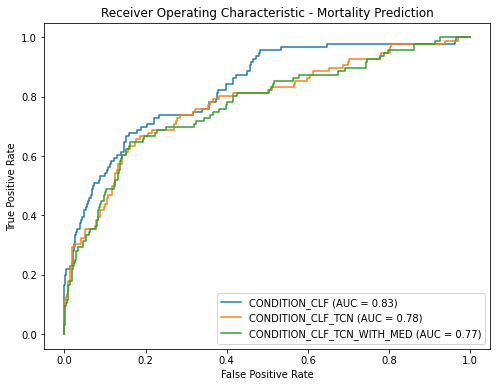

In [57]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_type in model_paths:
    for dropout in model_paths[model_type]:
        if dropout == 30:
            continue

        fpr, tpr, _ = roc_curve(1-mortality_gt[model_type][dropout],  mortality_preds[model_type][dropout])
#         auc = roc_auc_score(1-mortality_gt[model_type][dropout], mortality_preds[model_type][dropout])
#         ax.plot(fpr,tpr,label=f"{model_type}_{dropout}_auc{auc:.2f}")
    
        idx80 = np.where(tpr>.8)[0][0]
        tpr80 =  tpr[idx80]
        fpr80 = fpr[idx80]
        
        auprc = average_precision_score(1-mortality_gt[model_type][dropout],  mortality_preds[model_type][dropout])
        
        performance_metrics[model_type][dropout][0]['recall80'] = tpr80
        performance_metrics[model_type][dropout][0]['precision80'] = 1 - fpr80
        performance_metrics[model_type][dropout][0]['auprc'] = auprc
        
        RocCurveDisplay.from_predictions(
            1-mortality_gt[model_type][dropout],
            mortality_preds[model_type][dropout],
            name=f"{model_type}",
#             color=color,
            ax=ax,
#             plot_chance_level=(name=='Dobutamine'),
        )




_ = ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Receiver Operating Characteristic - Mortality Prediction",
)

plt.legend()

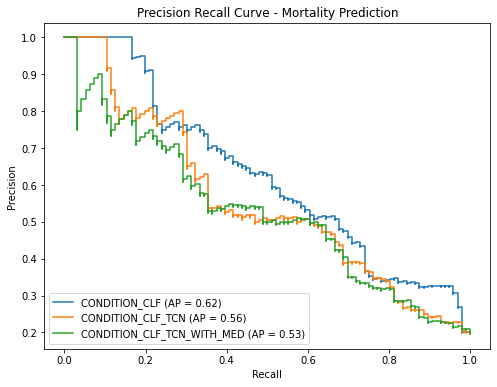

In [61]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_type in model_paths:
    for dropout in model_paths[model_type]:
        if dropout == 30:
            continue

        
        PrecisionRecallDisplay.from_predictions(
            1-mortality_gt[model_type][dropout],
            mortality_preds[model_type][dropout],
            name=f"{model_type}",
#             color=color,
            ax=ax,
#             plot_chance_level=(name=='Dobutamine'),
        )

_ = ax.set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision Recall Curve - Mortality Prediction",
)

In [60]:
round(performance_metrics[model_type][dropout][0]['test_roc'], 2)

0.62

(0.0, 1.0)

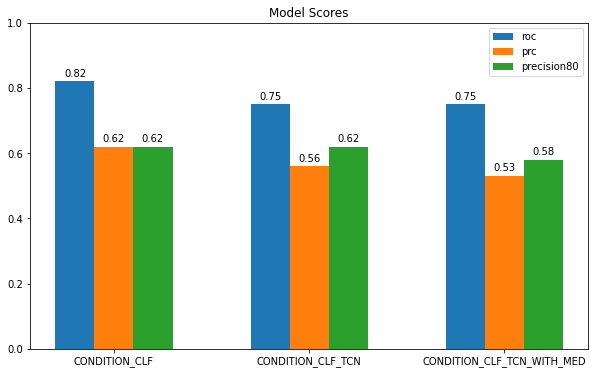

In [53]:
scores = {
    "roc":[],
    "prc":[],
    'precision80':[],
}

for model_type in model_paths:
    for dropout in model_paths[model_type]:
        if dropout == 30:
            continue
        scores["roc"].append(round(performance_metrics[model_type][dropout][0]['test_roc'], 2))
        scores["prc"].append(round(performance_metrics[model_type][dropout][0]['auprc'], 2))
        scores["precision80"].append(round(performance_metrics[model_type][dropout][0]['precision80'], 2))

models = [model_type for model_type in model_paths]


width = 0.25  # the width of the bars
multiplier = 0
x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(10, 6))

for attribute, measurement in scores.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1
    

ax.set_title('Model Scores')
ax.set_xticks(x + width, models)
ax.legend(loc='upper right')
ax.set_ylim(0, 1)

(0.0, 1.0)

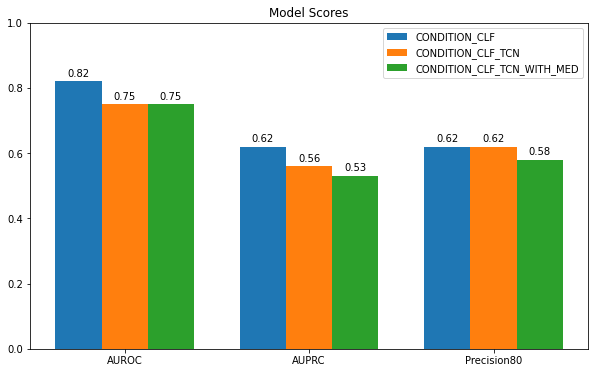

In [55]:
scores = {
    model_type: [] 
    for model_type in model_paths
}

for model_type in model_paths:
    for dropout in model_paths[model_type]:
        if dropout == 30:
            continue
        scores[model_type].append(round(performance_metrics[model_type][dropout][0]['test_roc'], 2))
        scores[model_type].append(round(performance_metrics[model_type][dropout][0]['auprc'], 2))
        scores[model_type].append(round(performance_metrics[model_type][dropout][0]['precision80'], 2))

x_scores = ['AUROC', 'AUPRC', 'Precision80']


width = 0.25  # the width of the bars
multiplier = 0
x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(10, 6))

for attribute, measurement in scores.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1
    

ax.set_title('Model Scores')
ax.set_xticks(x + width, x_scores)
ax.legend(loc='upper right')
ax.set_ylim(0, 1)

# 1 VS ALL

In [14]:
from utils.ClassCLF import MED_CLF

def binary_prob(arr, target):
    col_target = arr[:,target].reshape(-1,1)
    col_other = np.delete(arr, target, axis=1).sum(axis=1).reshape(-1,1)
    
    return col_target / (col_target + col_other)

In [4]:
model_file = "models/MED_CLF/0.2dropout-8-0.0005/version_0/epoch22-val_loss0.48514.ckpt"
config_file = "models/MED_CLF/0.2dropout-8-0.0005/version_0/model_config.p"
config = pickle_load(config_file)
device = 'cuda'

model = MED_CLF.load_from_checkpoint(checkpoint_path=model_file, config=config)
model.eval()
model.to(device)

med_label_gt = []
for sample in loader_test:
    med_label_gt.append(sample['med_label'].cpu().detach().numpy())
med_label_gt = np.concatenate(med_label_gt, axis=0)

med_preds = []
for X in tqdm(loader_test):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = torch.Tensor(X[k][j]).to(device)
        else:
            X[k] = torch.Tensor(X[k]).to(device)
    _, prob = model(X)
    med_preds.append(prob.cpu().detach().numpy())
med_preds = np.concatenate(med_preds, axis=0)

probmax = med_preds.max(axis=1).reshape(-1, 1)
med_label = np.where(med_preds == probmax, 1, 0)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:14<00:00,  1.10it/s]


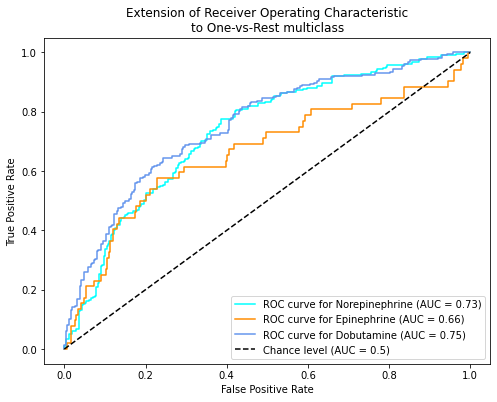

In [17]:
prob_norepinephrine = binary_prob(med_preds, 0)
med_label_gt_norepinephrine = med_label_gt[:, 0]

prob_epinephrine = binary_prob(med_preds, 1)
med_label_gt_epinephrine = med_label_gt[:, 1]

prob_dobutamine = binary_prob(med_preds, 2)
med_label_gt_dobutamine = med_label_gt[:, 2]


from itertools import cycle

fig, ax = plt.subplots(figsize=(8, 6))

colors = cycle(["aqua", "darkorange", "cornflowerblue"])
names = ['Norepinephrine', 'Epinephrine', 'Dobutamine']
labels_gt = [med_label_gt_norepinephrine, med_label_gt_epinephrine, med_label_gt_dobutamine]
probs = [prob_norepinephrine, prob_epinephrine, prob_dobutamine]
for label, prob, name, color in zip(labels_gt, probs, names, colors):
    RocCurveDisplay.from_predictions(
        label,
        prob,
        name=f"ROC curve for {name}",
        color=color,
        ax=ax,
        plot_chance_level=(name=='Dobutamine'),
    )

_ = ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest multiclass Receiver Operating Characteristic",
)

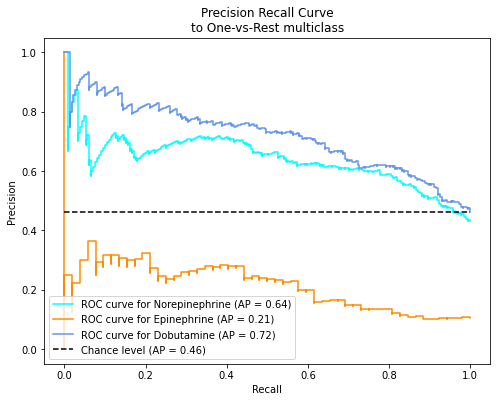

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = cycle(["aqua", "darkorange", "cornflowerblue"])
names = ['Norepinephrine', 'Epinephrine', 'Dobutamine']
labels_gt = [med_label_gt_norepinephrine, med_label_gt_epinephrine, med_label_gt_dobutamine]
probs = [prob_norepinephrine, prob_epinephrine, prob_dobutamine]
for label, prob, name, color in zip(labels_gt, probs, names, colors):
    PrecisionRecallDisplay.from_predictions(
        label,
        prob,
        name=f"ROC curve for {name}",
        color=color,
        ax=ax,
        plot_chance_level=(name=='Dobutamine'),
    )

_ = ax.set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision Recall Curve\nto One-vs-Rest multiclass",
)

# Dosage Trend CLF

In [20]:
from utils.ClassSOM import VASO_DOSAGE_PRED

In [21]:
model_file = "models/VASO_DOSAGE_PRED/32rnn-0.1dropout-16-0.0005/version_0/epoch38-val_loss0.42461.ckpt"
config_file = "models/VASO_DOSAGE_PRED/32rnn-0.1dropout-16-0.0005/version_0/model_config.p"
config = pickle_load(config_file)

model = VASO_DOSAGE_PRED.load_from_checkpoint(checkpoint_path=model_file, config=config)
model.eval()
model.to(device)

dosage_change_gt = []
med_dict = {med: [] for med in MED_BENCHMARK[:3]}
for i, sample in enumerate(loader_test):
    if sample['med_label'] == np.array([1, 0, 0]):
        med_dict['norepinephrine'].append(i)
    elif sample['med_label'] == np.array([0, 1, 0]):
        med_dict['epinephrine'].append(i)
    elif sample['med_label'] == np.array([0, 0, 1]):
        med_dict['dobutamine'].append(i)
    dosage_change_gt.append(sample['dosage_trend_bool'].cpu().detach().numpy())
dosage_change_gt = np.concatenate(dosage_change_gt, axis=0)

dosage_change = []
for X in tqdm(loader_test):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = torch.Tensor(X[k][j]).to(device)
        else:
            X[k] = torch.Tensor(X[k]).to(device)
    change = model(X)
    dosage_change.append(change.cpu().detach().numpy())
dosage_change = np.concatenate(dosage_change, axis=0)

probmax = dosage_change.max(axis=1).reshape(-1, 1)
dosage_change_bool = np.where(med_preds == probmax, 1, 0)

FileNotFoundError: [Errno 2] No such file or directory: 'models/VASO_PHYSIO_PRED/CNN-196hidden-5-5-0.1dropout-16-0.0005/version_0/'

In [22]:
config

{'device': 'cuda',
 'batchsize': 16,
 'lr': 0.0005,
 'ae_model_path': 'models/VASO_PHYSIO_PRED/CNN-196hidden-5-5-0.1dropout-16-0.0005/version_0/',
 'seq_len': 180,
 'n_feat': 7,
 'n_feat_med': 3,
 'rnn_hidden': 32,
 'dropout': 0.1}

# 1 VS 1

In [ ]:
from itertools import combinations

pair_list = list(combinations(np.unique(y), 2))
print(pair_list)

In [ ]:
pair_scores = []
mean_tpr = dict()

for ix, (label_a, label_b) in enumerate(pair_list):
    a_mask = y_test == label_a
    b_mask = y_test == label_b
    ab_mask = np.logical_or(a_mask, b_mask)

    a_true = a_mask[ab_mask]
    b_true = b_mask[ab_mask]

    idx_a = np.flatnonzero(label_binarizer.classes_ == label_a)[0]
    idx_b = np.flatnonzero(label_binarizer.classes_ == label_b)[0]

    fpr_a, tpr_a, _ = roc_curve(a_true, y_score[ab_mask, idx_a])
    fpr_b, tpr_b, _ = roc_curve(b_true, y_score[ab_mask, idx_b])

    mean_tpr[ix] = np.zeros_like(fpr_grid)
    mean_tpr[ix] += np.interp(fpr_grid, fpr_a, tpr_a)
    mean_tpr[ix] += np.interp(fpr_grid, fpr_b, tpr_b)
    mean_tpr[ix] /= 2
    mean_score = auc(fpr_grid, mean_tpr[ix])
    pair_scores.append(mean_score)

    fig, ax = plt.subplots(figsize=(6, 6))
    plt.plot(
        fpr_grid,
        mean_tpr[ix],
        label=f"Mean {label_a} vs {label_b} (AUC = {mean_score :.2f})",
        linestyle=":",
        linewidth=4,
    )
    RocCurveDisplay.from_predictions(
        a_true,
        y_score[ab_mask, idx_a],
        ax=ax,
        name=f"{label_a} as positive class",
    )
    RocCurveDisplay.from_predictions(
        b_true,
        y_score[ab_mask, idx_b],
        ax=ax,
        name=f"{label_b} as positive class",
        plot_chance_level=True,
    )
    ax.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title=f"{target_names[idx_a]} vs {label_b} ROC curves",
    )

print(f"Macro-averaged One-vs-One ROC AUC score:\n{np.average(pair_scores):.2f}")